<a href="https://colab.research.google.com/github/Tengoku1/CS109_Causality_Counterfactual_Model/blob/main/CS109_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Simulated Hidden Markov Model For CKD Disease Progression**

In [30]:
# Hidden Markov Model Simulation for CKD Disease Progression
# Colab-ready, no special packages needed

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# -----------------------------
# 1. Define hidden disease states
# -----------------------------
states = ["Healthy", "Early CKD", "Moderate CKD", "Severe CKD"]
n_states = len(states)

# Transition matrix: P(next_state | current_state)
A = np.array([
    [0.88, 0.10, 0.02, 0.00],
    [0.05, 0.80, 0.13, 0.02],
    [0.00, 0.08, 0.78, 0.14],
    [0.00, 0.01, 0.09, 0.90]
])

# Initial probabilities
pi = np.array([0.85, 0.10, 0.04, 0.01])

# --------------------------------------
# 2. Emission model: noisy medical labs
# --------------------------------------
# Features: [Creatinine, eGFR, Blood Pressure, Proteinuria]
means = np.array([
    [1.0, 95, 125, 0.3],   # Healthy / stable
    [1.3, 80, 135, 0.5],   # Mild dysfunction
    [1.7, 60, 142, 0.9],   # Moderate dysfunction
    [2.4, 38, 150, 1.5]    # Severe dysfunction
])
covs = np.array([
    np.diag([0.25, 18, 18, 0.35])**2,
    np.diag([0.35, 22, 20, 0.50])**2,
    np.diag([0.55, 18, 22, 0.70])**2,
    np.diag([0.90, 15, 25, 0.90])**2
])

# -----------------------------
# 3. Simulate patient trajectory
# -----------------------------
T = 15  # years / visits

hidden_states = []
observations = []

current_state = np.random.choice(n_states, p=pi)

for_t = range(T)
for t in for_t:
    hidden_states.append(current_state)

    obs = np.random.multivariate_normal(
        mean=means[current_state],
        cov=covs[current_state]
    )
    observations.append(obs)

    current_state = np.random.choice(n_states, p=A[current_state])

observations = np.array(observations)
extra_noise = np.random.normal(
    loc=0,
    scale=[0.2, 10, 10, 0.3],   # noise for [Creatinine, eGFR, BloodPressure, Proteinuria]
    size=observations.shape
)

observations_noisy = observations + extra_noise
df = pd.DataFrame(observations_noisy, columns=["Creatinine", "eGFR", "BloodPressure", "Proteinuria"])
df["True Hidden State"] = [states[i] for i in hidden_states]
df["Year"] = np.arange(1, T + 1)

df

,Creatinine,eGFR,BloodPressure,Proteinuria,True Hidden State,Year
0,1.270038,71.996084,131.657847,-0.198606,Healthy,1
1,0.839633,90.120587,149.545021,-0.017677,Healthy,2
2,0.457332,42.956547,151.260675,0.684381,Healthy,3
3,0.837604,83.788241,100.549309,1.103571,Healthy,4
4,0.730730,137.794163,128.175113,-0.096278,Healthy,5
5,1.522294,86.799056,119.800647,0.019027,Healthy,6
6,0.814263,81.187868,121.473353,-0.020991,Healthy,7
7,1.016958,102.800053,108.587797,-0.112492,Healthy,8
8,0.797357,84.065584,133.447509,-0.012497,Early CKD,9
9,0.694982,94.498368,154.218835,0.762273,Early CKD,10


In [31]:
# -----------------------------------
# 4. Viterbi Algorithm from scratch
# -----------------------------------
def viterbi(obs, pi, A, means, covs):
    T = len(obs)
    n_states = len(pi)

    log_delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    # Initial step
    for s in range(n_states):
        emission_prob = multivariate_normal.pdf(obs[0], means[s], covs[s])
        log_delta[0, s] = np.log(pi[s]) + np.log(emission_prob + 1e-12)

    # Recursion
    for t in range(1, T):
        for s in range(n_states):
            emission_prob = multivariate_normal.pdf(obs[t], means[s], covs[s])

            scores = log_delta[t-1] + np.log(A[:, s] + 1e-12)
            psi[t, s] = np.argmax(scores)
            log_delta[t, s] = np.max(scores) + np.log(emission_prob + 1e-12)

    # Backtracking
    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(log_delta[-1])

    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path

predicted_states = viterbi(observations_noisy, pi, A, means, covs)

df["Predicted Hidden State"] = [states[i] for i in predicted_states]
df

,Creatinine,eGFR,BloodPressure,Proteinuria,True Hidden State,Year,Predicted Hidden State
0,1.270038,71.996084,131.657847,-0.198606,Healthy,1,Healthy
1,0.839633,90.120587,149.545021,-0.017677,Healthy,2,Healthy
2,0.457332,42.956547,151.260675,0.684381,Healthy,3,Healthy
3,0.837604,83.788241,100.549309,1.103571,Healthy,4,Healthy
4,0.730730,137.794163,128.175113,-0.096278,Healthy,5,Healthy
5,1.522294,86.799056,119.800647,0.019027,Healthy,6,Healthy
6,0.814263,81.187868,121.473353,-0.020991,Healthy,7,Healthy
7,1.016958,102.800053,108.587797,-0.112492,Healthy,8,Healthy
8,0.797357,84.065584,133.447509,-0.012497,Early CKD,9,Healthy
9,0.694982,94.498368,154.218835,0.762273,Early CKD,10,Healthy


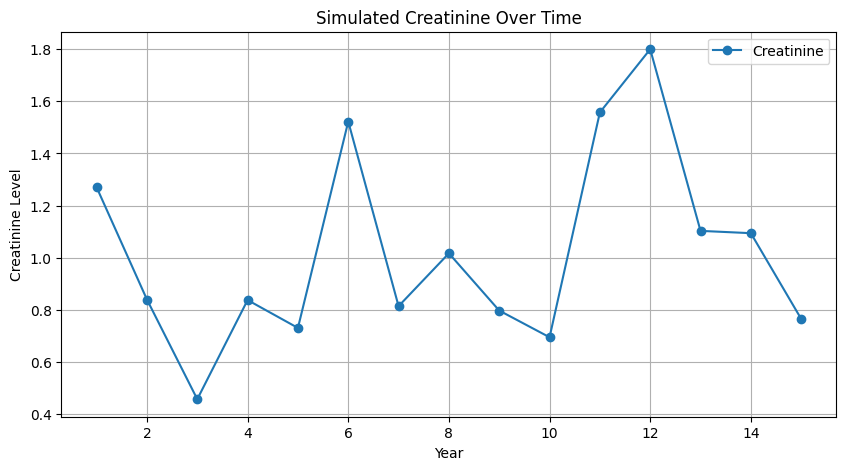

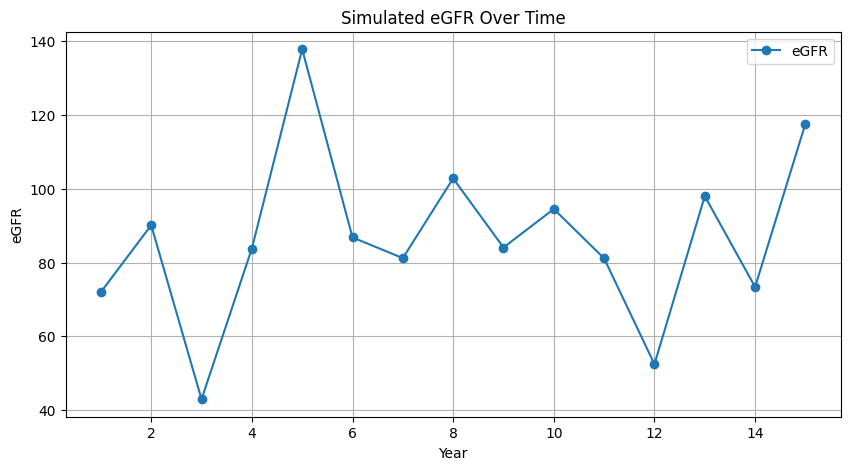

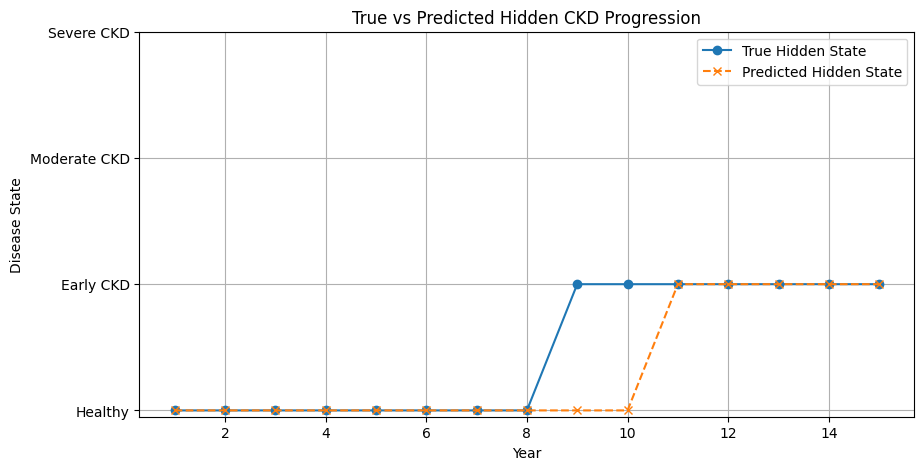

In [32]:
# -----------------------------
# 5. Visualization
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["Creatinine"], marker="o", label="Creatinine")
plt.xlabel("Year")
plt.ylabel("Creatinine Level")
plt.title("Simulated Creatinine Over Time")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(df["Year"], df["eGFR"], marker="o", label="eGFR")
plt.xlabel("Year")
plt.ylabel("eGFR")
plt.title("Simulated eGFR Over Time")
plt.legend()
plt.grid(True)
plt.show()

state_nums_true = hidden_states
state_nums_pred = predicted_states

plt.figure(figsize=(10, 5))
plt.plot(df["Year"], state_nums_true, marker="o", label="True Hidden State")
plt.plot(df["Year"], state_nums_pred, marker="x", linestyle="--", label="Predicted Hidden State")
plt.yticks(range(n_states), states)
plt.xlabel("Year")
plt.ylabel("Disease State")
plt.title("True vs Predicted Hidden CKD Progression")
plt.legend()
plt.grid(True)
plt.show()

In [33]:
accuracy = np.mean(np.array(hidden_states) == predicted_states)

print(f"Hidden state prediction accuracy: {accuracy:.2%}")

comparison = df[["Year", "True Hidden State", "Predicted Hidden State",
                 "Creatinine", "eGFR", "BloodPressure", "Proteinuria"]]

comparison

Hidden state prediction accuracy: 86.67%


,Year,True Hidden State,Predicted Hidden State,Creatinine,eGFR,BloodPressure,Proteinuria
0,1,Healthy,Healthy,1.270038,71.996084,131.657847,-0.198606
1,2,Healthy,Healthy,0.839633,90.120587,149.545021,-0.017677
2,3,Healthy,Healthy,0.457332,42.956547,151.260675,0.684381
3,4,Healthy,Healthy,0.837604,83.788241,100.549309,1.103571
4,5,Healthy,Healthy,0.730730,137.794163,128.175113,-0.096278
5,6,Healthy,Healthy,1.522294,86.799056,119.800647,0.019027
6,7,Healthy,Healthy,0.814263,81.187868,121.473353,-0.020991
7,8,Healthy,Healthy,1.016958,102.800053,108.587797,-0.112492
8,9,Early CKD,Healthy,0.797357,84.065584,133.447509,-0.012497
9,10,Early CKD,Healthy,0.694982,94.498368,154.218835,0.762273


**Longitudal Study Using Real Data**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

In [ ]:
"""
Apply a semi-supervised Hidden Markov Model to the MIMIC-IV demo kidney progression dataset.

This script:
1. Loads mimic_demo_kidney_hmm_progression_dataset.csv
2. Creates coarse kidney-function states from estimated eGFR stage
3. Estimates an HMM transition matrix from patient trajectories
4. Estimates Gaussian emission parameters from kidney-related labs
5. Runs Viterbi decoding for each patient
6. Saves a progression dataset with predicted hidden states

Designed for Google Colab or local Python.
"""

import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal

INPUT_PATH = "/content/mimic_demo_kidney_hmm_progression_dataset.csv"
OUTPUT_PATH = "/content/mimic_demo_hmm_predictions.csv"
TRANSITION_PATH = "/content/mimic_demo_hmm_transition_matrix.csv"
EMISSION_PATH = "/content/mimic_demo_hmm_emission_means.csv"

FEATURES = [
    "creatinine_mg_dl",
    "bun_mg_dl",
    "sodium_meq_l",
    "potassium_meq_l",
    "bicarbonate_meq_l",
]

STATE_NAMES = [
    "State 0: Normal/Mild kidney function",
    "State 1: Moderate kidney dysfunction",
    "State 2: Severe kidney dysfunction",
    "State 3: Kidney failure range",
]


def map_egfr_stage(stage):
    """Map detailed eGFR stage into 4 broader HMM states."""
    if pd.isna(stage):
        return np.nan
    stage = str(stage)
    if stage.startswith("G1") or stage.startswith("G2"):
        return 0
    if stage.startswith("G3"):
        return 1
    if stage.startswith("G4"):
        return 2
    if stage.startswith("G5"):
        return 3
    return np.nan


def prepare_data(df):
    df = df.copy()
    df["charttime"] = pd.to_datetime(df["charttime"])
    df = df.sort_values(["subject_id", "charttime", "visit_number"])

    df["proxy_state"] = df["egfr_stage_estimated"].apply(map_egfr_stage)

    # Keep rows that have at least one useful lab feature.
    df = df.dropna(subset=FEATURES, how="all")

    # Impute within each patient first, then use global medians.
    for col in FEATURES:
        df[col] = df.groupby("subject_id")[col].transform(lambda s: s.ffill().bfill())
        df[col] = df[col].fillna(df[col].median())

    return df


def estimate_initial_probs(df, n_states):
    first_states = (
        df.dropna(subset=["proxy_state"])
          .sort_values(["subject_id", "charttime"])
          .groupby("subject_id")["proxy_state"]
          .first()
          .astype(int)
    )
    counts = np.ones(n_states)  # Laplace smoothing
    for s in first_states:
        counts[s] += 1
    return counts / counts.sum()


def estimate_transition_matrix(df, n_states):
    counts = np.ones((n_states, n_states))  # Laplace smoothing
    for _, group in df.dropna(subset=["proxy_state"]).groupby("subject_id"):
        states = group.sort_values("charttime")["proxy_state"].astype(int).to_numpy()
        for a, b in zip(states[:-1], states[1:]):
            counts[a, b] += 1
    return counts / counts.sum(axis=1, keepdims=True)


def estimate_emissions(df, features, n_states):
    means = []
    covs = []
    global_var = df[features].var().replace(0, 1e-3).to_numpy()

    for s in range(n_states):
        subset = df[df["proxy_state"] == s][features]
        if len(subset) < 3:
            mu = df[features].mean().to_numpy()
            var = global_var
        else:
            mu = subset.mean().to_numpy()
            var = subset.var().fillna(0).to_numpy()
            var = np.where(var < 1e-5, global_var, var)

        cov = np.diag(var + 1e-3)
        means.append(mu)
        covs.append(cov)

    return np.array(means), np.array(covs)


def viterbi(obs, pi, A, means, covs):
    T = len(obs)
    n_states = len(pi)

    log_delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    for s in range(n_states):
        log_emission = multivariate_normal.logpdf(obs[0], mean=means[s], cov=covs[s], allow_singular=True)
        log_delta[0, s] = np.log(pi[s] + 1e-12) + log_emission

    for t in range(1, T):
        for s in range(n_states):
            log_emission = multivariate_normal.logpdf(obs[t], mean=means[s], cov=covs[s], allow_singular=True)
            scores = log_delta[t - 1] + np.log(A[:, s] + 1e-12)
            psi[t, s] = np.argmax(scores)
            log_delta[t, s] = np.max(scores) + log_emission

    path = np.zeros(T, dtype=int)
    path[-1] = np.argmax(log_delta[-1])

    for t in range(T - 2, -1, -1):
        path[t] = psi[t + 1, path[t + 1]]

    return path


def main():
    df = pd.read_csv(INPUT_PATH)
    df = prepare_data(df)

    n_states = len(STATE_NAMES)
    pi = estimate_initial_probs(df, n_states)
    A = estimate_transition_matrix(df, n_states)
    means, covs = estimate_emissions(df, FEATURES, n_states)

    prediction_chunks = []
    for subject_id, group in df.groupby("subject_id"):
        group = group.sort_values("charttime").copy()
        obs = group[FEATURES].to_numpy()
        path = viterbi(obs, pi, A, means, covs)
        group["predicted_hmm_state"] = path
        group["predicted_hmm_state_name"] = [STATE_NAMES[i] for i in path]
        prediction_chunks.append(group)

    out = pd.concat(prediction_chunks, ignore_index=True)

    # Add a simple progression flag.
    out["state_change_from_previous_visit"] = out.groupby("subject_id")["predicted_hmm_state"].diff()
    out["progressed_from_previous_visit"] = out["state_change_from_previous_visit"] > 0
    out["improved_from_previous_visit"] = out["state_change_from_previous_visit"] < 0

    out.to_csv(OUTPUT_PATH, index=False)

    transition_df = pd.DataFrame(A, index=STATE_NAMES, columns=STATE_NAMES)
    transition_df.to_csv(TRANSITION_PATH)

    emission_df = pd.DataFrame(means, columns=FEATURES)
    emission_df.insert(0, "state_name", STATE_NAMES)
    emission_df.to_csv(EMISSION_PATH, index=False)

    print("Saved:", OUTPUT_PATH)
    print("Saved:", TRANSITION_PATH)
    print("Saved:", EMISSION_PATH)
    print("Rows:", len(out))
    print("Subjects:", out["subject_id"].nunique())
    print("\nInitial probabilities:")
    for name, val in zip(STATE_NAMES, pi):
        print(f"{name}: {val:.3f}")
    print("\nTransition matrix:")
    print(transition_df.round(3))


main()


Saved: /content/mimic_demo_hmm_predictions.csv
Saved: /content/mimic_demo_hmm_transition_matrix.csv
Saved: /content/mimic_demo_hmm_emission_means.csv
Rows: 2473
Subjects: 100

Initial probabilities:
State 0: Normal/Mild kidney function: 0.692
State 1: Moderate kidney dysfunction: 0.231
State 2: Severe kidney dysfunction: 0.019
State 3: Kidney failure range: 0.058

Transition matrix:
                                      State 0: Normal/Mild kidney function  \
State 0: Normal/Mild kidney function                                 0.956   
State 1: Moderate kidney dysfunction                                 0.103   
State 2: Severe kidney dysfunction                                   0.006   
State 3: Kidney failure range                                        0.008   

                                      State 1: Moderate kidney dysfunction  \
State 0: Normal/Mild kidney function                                 0.039   
State 1: Moderate kidney dysfunction                               

Example subject: 10035631


,subject_id,charttime,days_since_first_lab,creatinine_mg_dl,estimated_egfr_2021,predicted_hmm_state_name
1931,10035631,2112-09-17 20:30:00,0.000000,1.1,75.430095,State 0: Normal/Mild kidney function
1932,10035631,2112-09-19 06:15:00,1.406250,0.9,95.967651,State 0: Normal/Mild kidney function
1933,10035631,2112-09-20 04:23:00,2.328472,0.8,99.442705,State 0: Normal/Mild kidney function
1934,10035631,2112-09-21 00:00:00,3.145833,0.8,99.442705,State 0: Normal/Mild kidney function
1935,10035631,2112-09-21 07:49:00,3.471528,0.8,99.442705,State 0: Normal/Mild kidney function
1936,10035631,2112-09-21 16:26:00,3.830556,0.9,95.967651,State 0: Normal/Mild kidney function
1937,10035631,2112-09-21 22:59:00,4.103472,0.9,95.967651,State 0: Normal/Mild kidney function
1938,10035631,2112-09-22 11:08:00,4.609722,0.9,95.967651,State 0: Normal/Mild kidney function
1939,10035631,2112-09-23 00:31:00,5.167361,0.9,95.967651,State 0: Normal/Mild kidney function
1940,10035631,2112-09-23 12:05:00,5.649306,0.8,99.442705,State 0: Normal/Mild kidney function


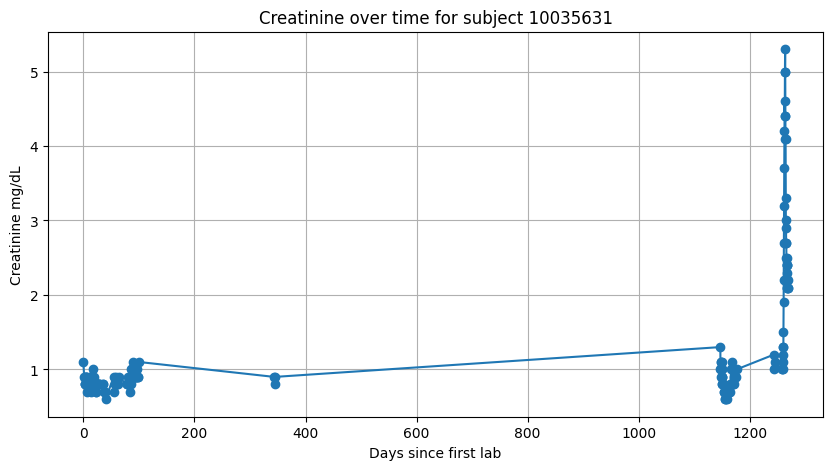

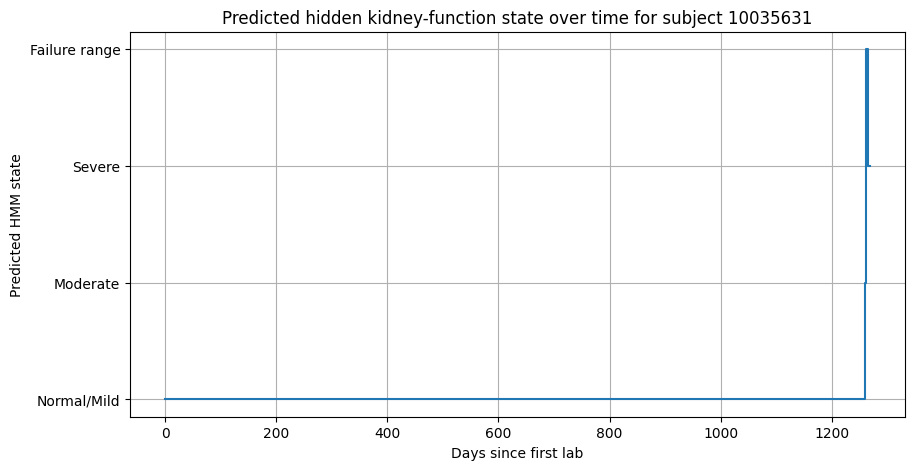

In [ ]:
pred = pd.read_csv('/content/mimic_demo_hmm_predictions.csv')
pred['charttime'] = pd.to_datetime(pred['charttime'])

# Choose the patient with the most rows.
example_subject = pred['subject_id'].value_counts().idxmax()
g = pred[pred['subject_id'] == example_subject].sort_values('charttime')

print('Example subject:', example_subject)
display(g[['subject_id','charttime','days_since_first_lab','creatinine_mg_dl','estimated_egfr_2021','predicted_hmm_state_name']].head(20))

plt.figure(figsize=(10,5))
plt.plot(g['days_since_first_lab'], g['creatinine_mg_dl'], marker='o')
plt.xlabel('Days since first lab')
plt.ylabel('Creatinine mg/dL')
plt.title(f'Creatinine over time for subject {example_subject}')
plt.grid(True)
plt.show()

plt.figure(figsize=(10,5))
plt.step(g['days_since_first_lab'], g['predicted_hmm_state'], where='post')
plt.yticks([0,1,2,3], ['Normal/Mild','Moderate','Severe','Failure range'])
plt.xlabel('Days since first lab')
plt.ylabel('Predicted HMM state')
plt.title(f'Predicted hidden kidney-function state over time for subject {example_subject}')
plt.grid(True)
plt.show()


**Accuracy Evaluation**

In [11]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Load your HMM prediction dataset
df = pd.read_csv("mimic_demo_hmm_predictions.csv")

# Check columns
print(df.columns)
df.head()

Index(['subject_id', 'hadm_id', 'visit_number', 'charttime',
       'days_since_first_lab', 'days_since_admission', 'admittime',
       'dischtime', 'gender', 'anchor_age', 'race', 'admission_type',
       'insurance', 'hospital_expire_flag', 'ckd_label', 'subject_ckd_ever',
       'diabetes_label', 'subject_diabetes_ever', 'hypertension_label',
       'subject_hypertension_ever', 'aki_label', 'subject_aki_ever',
       'creatinine_mg_dl', 'estimated_egfr_2021', 'egfr_stage_estimated',
       'bun_mg_dl', 'sodium_meq_l', 'potassium_meq_l', 'chloride_meq_l',
       'bicarbonate_meq_l', 'albumin_g_dl', 'glucose_mg_dl', 'n_timepoints',
       'ckd_icd_codes', 'ckd_icd_titles', 'proxy_state', 'predicted_hmm_state',
       'predicted_hmm_state_name', 'state_change_from_previous_visit',
       'progressed_from_previous_visit', 'improved_from_previous_visit'],
      dtype='object')


,subject_id,hadm_id,visit_number,charttime,days_since_first_lab,days_since_admission,admittime,dischtime,gender,anchor_age,...,glucose_mg_dl,n_timepoints,ckd_icd_codes,ckd_icd_titles,proxy_state,predicted_hmm_state,predicted_hmm_state_name,state_change_from_previous_visit,progressed_from_previous_visit,improved_from_previous_visit
0,10000032,22595853,1,2180-05-07 05:05:00,0.000000,0.279167,2180-05-06 22:23:00,2180-05-07 17:15:00,F,52,...,99.0,9,NaN,NaN,0.0,0,State 0: Normal/Mild kidney function,NaN,False,False
1,10000032,22841357,2,2180-06-27 05:10:00,51.003472,0.446528,2180-06-26 18:27:00,2180-06-27 18:49:00,F,52,...,71.0,9,NaN,NaN,0.0,0,State 0: Normal/Mild kidney function,0.0,False,False
2,10000032,29079034,3,2180-07-23 21:45:00,77.694444,0.381944,2180-07-23 12:35:00,2180-07-25 17:55:00,F,52,...,115.0,9,NaN,NaN,0.0,0,State 0: Normal/Mild kidney function,0.0,False,False
3,10000032,29079034,4,2180-07-24 06:35:00,78.062500,0.750000,2180-07-23 12:35:00,2180-07-25 17:55:00,F,52,...,107.0,9,NaN,NaN,0.0,0,State 0: Normal/Mild kidney function,0.0,False,False
4,10000032,29079034,5,2180-07-25 04:45:00,78.986111,1.673611,2180-07-23 12:35:00,2180-07-25 17:55:00,F,52,...,121.0,9,NaN,NaN,0.0,0,State 0: Normal/Mild kidney function,0.0,False,False


In [13]:
# True label from diagnosis code
y_true = df["ckd_label"]

# HMM prediction:
# 0 means stable
# 1 means above stable
y_pred = (df["predicted_hmm_state"] > 0).astype(int)

df["hmm_predicted_ckd_like"] = y_pred

df[["subject_id", "charttime", "ckd_label", "predicted_hmm_state", "predicted_hmm_state_name", "hmm_predicted_ckd_like"]].head()

,subject_id,charttime,ckd_label,predicted_hmm_state,predicted_hmm_state_name,hmm_predicted_ckd_like
0,10000032,2180-05-07 05:05:00,0,0,State 0: Normal/Mild kidney function,0
1,10000032,2180-06-27 05:10:00,0,0,State 0: Normal/Mild kidney function,0
2,10000032,2180-07-23 21:45:00,0,0,State 0: Normal/Mild kidney function,0
3,10000032,2180-07-24 06:35:00,0,0,State 0: Normal/Mild kidney function,0
4,10000032,2180-07-25 04:45:00,0,0,State 0: Normal/Mild kidney function,0


In [14]:
cm = confusion_matrix(y_true, y_pred)

tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix")
print(cm)

print()
print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

Confusion Matrix
[[1334  338]
 [ 105  696]]

True Negatives: 1334
False Positives: 338
False Negatives: 105
True Positives: 696


In [15]:
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
specificity = tn / (tn + fp)
f1 = f1_score(y_true, y_pred)

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Sensitivity / Recall",
        "Specificity",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        specificity,
        f1
    ]
})

metrics

,Metric,Value
0,Accuracy,0.820865
1,Precision,0.673114
2,Sensitivity / Recall,0.868914
3,Specificity,0.797847
4,F1 Score,0.758583


In [16]:
print(f"Accuracy: {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Sensitivity / Recall: {recall:.3f}")
print(f"Specificity: {specificity:.3f}")
print(f"F1 Score: {f1:.3f}")

Accuracy: 0.821
Precision: 0.673
Sensitivity / Recall: 0.869
Specificity: 0.798
F1 Score: 0.759


In [17]:
comparison_table = pd.crosstab(
    df["ckd_label"],
    df["hmm_predicted_ckd_like"],
    rownames=["CKD Label"],
    colnames=["HMM Predicted CKD-like"]
)

comparison_table

HMM Predicted CKD-like,0,1
CKD Label,,
0,1334,338
1,105,696


In [19]:
percent_above_stable = df.groupby("ckd_label")["hmm_predicted_ckd_like"].mean() * 100

percent_above_stable = percent_above_stable.reset_index()
percent_above_stable.columns = ["ckd_label", "percent_predicted_above_stable"]

percent_above_stable

,ckd_label,percent_predicted_above_stable
0,0,20.215311
1,1,86.891386


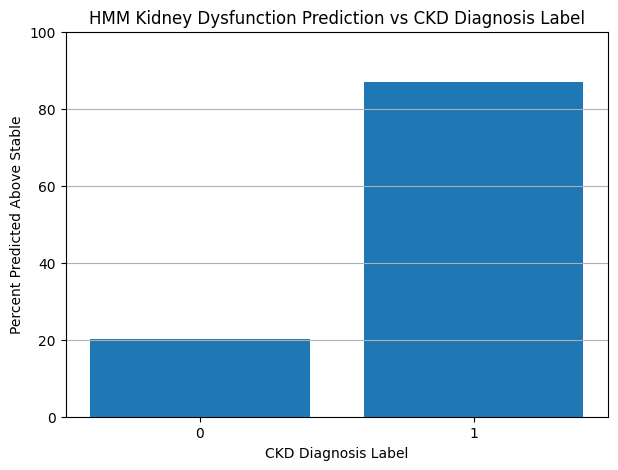

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
plt.bar(
    percent_above_stable["ckd_label"].astype(str),
    percent_above_stable["percent_predicted_above_stable"]
)

plt.xlabel("CKD Diagnosis Label")
plt.ylabel("Percent Predicted Above Stable")
plt.title("HMM Kidney Dysfunction Prediction vs CKD Diagnosis Label")
plt.ylim(0, 100)
plt.grid(axis="y")
plt.show()